# 量子AND门和量子OR门
## 布尔可满足性问题（boolean SATisfiablity problem, SAT）
**布尔表达式**：由运算符AND、OR、NOT加上变量以及括号组成的表达式

我们以HR审查求职者简历(curriculum vitae)为例，为了简化问题，我们规定一份简历需要包含以下部分：
+ 是否有护照或永久居住证
+ 是否驾驶证或毕业证
+ 是否成年
+ 是否有出生证明或社保

用Python的布尔表达式就可以写成如下形式：

In [1]:
def CV_checker(hasPassport, hasPermanentResidentCard, 
               hasDriverLicense, hasDiploma,
              isAdult,
              hasBirthCertificate, hasSocialCare):
    return (hasPassport or hasPermanentResidentCard) and \
           (hasDriverLicense or hasDiploma) and isAdult and \
           (hasBirthCertificate or hasSocialCare)

In [2]:
import itertools
works=[]
doesnt_work=[]
for combo in itertools.product([True,False],repeat=7):
    if CV_checker(combo[0],combo[1],combo[2],combo[3],combo[4],combo[5],combo[6]):
        works+=[combo]
    else:
        doesnt_work+=[combo]
print(len(works))
print(len(doesnt_work))

27
101


通过暴力遍历，我们知道了在$2^7$种可能的简历中，只有27种是符合标准的简历。可以想象如果审查项目增加至$18$种后，就需要检查$2^{18}$种可能的排列，其中又会有多少种简历符合标准，又有多少种简历不符合标准。

类似地，意欲得到满足布尔表达式的所有组合的过程被称为**布尔可满足性问题**（Boolean Satisfiability Problem, SAT）

## 关于3SAT的经典实现
通过and, or和not运算符，我们可以将任何表达式重写为**每个部分最多包含三个变量的形式**，这在算法分析中很有用，如有必要，还可以引入哑元（dummy variable）以简化算法分析：

In [3]:
a = b = c = d = True
(not a or b or d) and \
(not b or c or d) and \
(a or not c or d) and \
(not a or not b or not d) and \
(b or not c or not d) and \
(not a or c or not d) and \
(a or b or c) and \
(not a or not b or not c)

False

对应的SAT问题将研究哪一种a,b,c和d的组合会使该表达式判断为True。

由于我们限制每部分最多包含三个变量，因此我们称类似的布尔满足性问题为**3SAT**

In [4]:
def checker(f, candidate):
    """
    f: 以比特字符串为参数的函数，我们规定最右侧的字符为第0个比特
    candidate: 比特字符串
    """
    return(f(candidate))

In [5]:
def try_all_inputs(f, len_input):
    import itertools
    result=[]
    for candidate in ["".join(seq) for seq in itertools.product("01", repeat=len_input)]:
        if checker(f, candidate):
            result += [candidate]
    return result

In [6]:
def is_satisfiable(f, len_input):
    return len(try_all_inputs(f,len_input)) > 0

In [7]:
def a_3sat_function_4(binary_string):
    binary_list = [int(i) for i in binary_string]
    binary_list.reverse()
    a,b,c,d = binary_list[0 : 4]
    # 模式匹配
    # binary_string = "0110" -> list = ['0', '1', '1', '0'] -reverse()-> list = ['0', '1', '1', '0']
    # a, b, c, d = binary_list[0 : 4] <=> a = binary_list[0], b = binary_list[1] ....
    return (not a or b or d) and \
            (not b or c or d) and \
            (a or not c or d) and \
            (not a or not b or not d) and \
            (b or not c or not d) and \
            (not a or c or not d) and \
            (a or b or c) and \
            (not a or not b or not c)

传入a_3sat_function_4函数，即可获知是否存在满足的组合并将其打印出来

In [8]:
print(is_satisfiable(a_3sat_function_4,4))
print(try_all_inputs(a_3sat_function_4,4))

True
['1010', '1110']


## 量子AND门和量子OR门
### 量子AND门——Toffoli门
在逻辑门领域我们经常使用**真值表**去描述一个逻辑门的作用方式。对于经典逻辑门，有下面三种真值表：
![](07_2.png)

下图即是量子AND门的真值表
![](07_1.png)

如上图所示，量子AND门或者说Toffli门是一个三比特量子门。

对比最后两行和其他两行的结果不难发现，只有在两个控制位量子比特均为1时，才决定反转目标位量子比特，因此，Toffoli门也被称为控-控-非门（Controlled-Controlled-NOT Gate, CCNOT门），缩写为ccx。

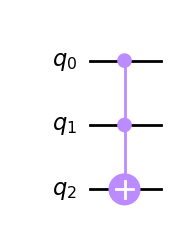

In [9]:
from qiskit import QuantumCircuit
circ = QuantumCircuit(3)
circ.ccx(0, 1, 2)
circ.draw('mpl')

### 量子OR门
可以根据c'的表达式发现，OR门与AND门有着类似的结构，因此我们可以借助Toffoli门间接实现OR门

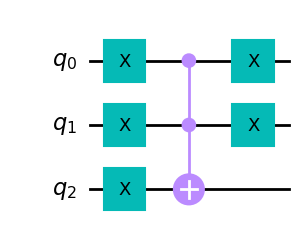

In [10]:
circ = QuantumCircuit(3)
circ.x(0)
circ.x(1)
circ.x(2)
circ.ccx(0, 1, 2)
circ.x(0)
circ.x(1)
circ.draw('mpl')

### 逻辑门的组合
实现的思路就是先选择两个量子比特进行计算，将结果保存在一个临时比特当中，之后再将临时比特和第三个量子比特进行逻辑运算：

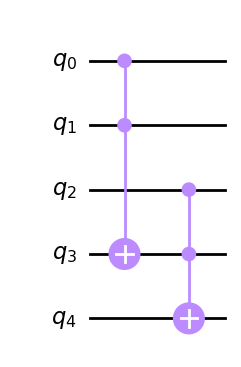

In [11]:
circ = QuantumCircuit(5)
circ.ccx(0, 1, 3)
circ.ccx(2, 3, 4)
circ.draw('mpl')

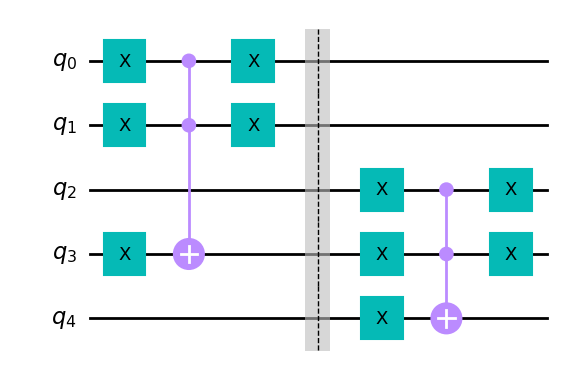

In [12]:
circ = QuantumCircuit(5)
circ.x(0)
circ.x(1)
circ.x(3)
circ.ccx(0, 1, 3)
circ.x(0)
circ.x(1)
circ.barrier(range(5))
circ.x(2)
circ.x(3)
circ.x(4)
circ.ccx(2, 3, 4)
circ.x(2)
circ.x(3)
circ.draw('mpl')